In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [57]:
file_path = r"C:\Projects\SPD-Track-Parameter-Prediction\spd_complete_training copy.tsv"

In [58]:

input_file = "C:\Projects\SPD-Track-Parameter-Prediction\spd_complete_training copy.tsv"
output_file = "signal_hits.tsv"

header = [
    "event_id",
    "x",
    "y",
    "z",
    "station",
    "track_id",
    "px",
    "py",
    "pz",
    "vertex_x",
    "vertex_y",
    "vertex_z"
]

In [61]:
with open(input_file, "r") as file, open(output_file, "w", newline="") as outfile:
    outfile.write("\t".join(header) + "\n")
    total_lines = 0
    signal_hits = 0
    noise_hits = 0

    for line in file:

        total_lines = total_lines + 1

        values = line.strip().split("\t")

        if len(values) == 12:
            outfile.write(line)
            signal_hits += 1

        else:
            noise_hits += 1


print("Total lines :", total_lines)
print("Signal hits :", signal_hits)
print("Noise hits  :", noise_hits)
print("Saved file  :", output_file)

Total lines : 2240683
Signal hits : 1695528
Noise hits  : 545155
Saved file  : signal_hits.tsv


In [62]:
real_hit_file_path = r"C:\Projects\SPD-Track-Parameter-Prediction\data\processed\signal_hits.tsv"

In [63]:
columns = [
    "event_id",
    "x",
    "y",
    "z",
    "station",
    "track_id",
    "px",
    "py",
    "pz",
    "vertex_x",
    "vertex_y",
    "vertex_z"
]

df = pd.read_csv(real_hit_file_path,sep="\t")

print(df.head())

   event_id           x           y           z  station  track_id  \
0         0 -239.513881 -124.766384  785.127241        1         0   
1         0 -253.874712 -134.044343  826.407469        2         0   
2         0 -268.044523 -143.534264  867.458676        3         0   
3         0 -282.397518 -153.034025  908.811465        4         0   
4         0 -296.584347 -162.728275  950.247964        5         0   

           px          py          pz  vertex_x  vertex_y    vertex_z  
0 -311.860522 -197.910793  887.989811  -3.79061  9.111583  135.319151  
1 -309.713768 -201.253694  887.989811  -3.79061  9.111583  135.319151  
2 -307.530110 -204.574922  887.989811  -3.79061  9.111583  135.319151  
3 -305.309684 -207.874155  887.989811  -3.79061  9.111583  135.319151  
4 -303.052623 -211.151072  887.989811  -3.79061  9.111583  135.319151  


In [64]:
df

,event_id,x,y,z,station,track_id,px,py,pz,vertex_x,vertex_y,vertex_z
0,0,-239.513881,-124.766384,785.127241,1,0,-311.860522,-197.910793,887.989811,-3.790610,9.111583,135.319151
1,0,-253.874712,-134.044343,826.407469,2,0,-309.713768,-201.253694,887.989811,-3.790610,9.111583,135.319151
2,0,-268.044523,-143.534264,867.458676,3,0,-307.530110,-204.574922,887.989811,-3.790610,9.111583,135.319151
3,0,-282.397518,-153.034025,908.811465,4,0,-305.309684,-207.874155,887.989811,-3.790610,9.111583,135.319151
4,0,-296.584347,-162.728275,950.247964,5,0,-303.052623,-211.151072,887.989811,-3.790610,9.111583,135.319151
...,...,...,...,...,...,...,...,...,...,...,...,...
1695523,9999,-699.242358,349.657687,241.741081,31,3,-789.538373,293.450052,102.077068,11.466804,6.578658,146.749168
1695524,9999,-715.147703,355.695225,243.706152,32,3,-790.916579,289.714929,102.077068,11.466804,6.578658,146.749168
1695525,9999,-731.468982,361.467293,245.744318,33,3,-792.277469,285.972354,102.077068,11.466804,6.578658,146.749168
1695526,9999,-747.905804,367.124577,248.094685,34,3,-793.621006,282.222384,102.077068,11.466804,6.578658,146.749168


In [65]:
len(df)

1695528

In [66]:
df["event_id"].unique()

array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(9994,))

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695528 entries, 0 to 1695527
Data columns (total 12 columns):
 #   Column    Dtype  
---  ------    -----  
 0   event_id  int64  
 1   x         float64
 2   y         float64
 3   z         float64
 4   station   int64  
 5   track_id  int64  
 6   px        float64
 7   py        float64
 8   pz        float64
 9   vertex_x  float64
 10  vertex_y  float64
 11  vertex_z  float64
dtypes: float64(9), int64(3)
memory usage: 155.2 MB


In [68]:
df.isnull().sum()

event_id    0
x           0
y           0
z           0
station     0
track_id    0
px          0
py          0
pz          0
vertex_x    0
vertex_y    0
vertex_z    0
dtype: int64

In [69]:
df["event_id"].value_counts()

event_id
54      315
31      315
9968    315
9932    315
6       315
       ... 
6926      5
9401      4
9576      3
3650      3
7042      3
Name: count, Length: 9994, dtype: int64

In [70]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1695523    False
1695524    False
1695525    False
1695526    False
1695527    False
Length: 1695528, dtype: bool

In [71]:
df.describe()

,event_id,x,y,z,station,track_id,px,py,pz,vertex_x,vertex_y,vertex_z
count,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06,1.695528e+06
mean,5.006272e+03,3.664121e-02,4.935036e-01,3.879752e-01,1.782788e+01,2.666061e+00,-7.312467e-02,-7.285049e-02,2.285106e+00,-6.362488e-02,4.500619e-03,-1.553782e+00
std,2.882817e+03,4.116456e+02,4.128892e+02,6.436757e+02,1.008713e+01,2.213206e+00,4.296910e+02,4.323444e+02,6.860800e+02,1.000680e+01,9.959030e+00,1.731313e+02
min,0.000000e+00,-8.502679e+02,-8.502142e+02,-2.386012e+03,1.000000e+00,0.000000e+00,-9.976812e+02,-9.997155e+02,-7.998485e+03,-3.688903e+01,-3.910639e+01,-2.999917e+02
25%,2.522000e+03,-3.323565e+02,-3.347549e+02,-3.309033e+02,9.000000e+00,1.000000e+00,-2.974372e+02,-3.014202e+02,-2.563167e+02,-6.757704e+00,-6.662944e+00,-1.513997e+02
50%,5.005000e+03,-3.558180e-01,2.758164e+00,1.076626e+00,1.800000e+01,2.000000e+00,4.791235e-01,2.473216e+00,3.089177e+00,1.191840e-01,-6.179100e-02,-7.984360e-01
75%,7.504000e+03,3.334788e+02,3.344418e+02,3.339689e+02,2.700000e+01,4.000000e+00,2.975292e+02,2.993127e+02,2.646558e+02,6.537959e+00,6.794803e+00,1.469613e+02
max,9.999000e+03,8.502183e+02,8.502288e+02,2.386084e+03,3.500000e+01,8.000000e+00,9.985780e+02,9.986960e+02,8.427400e+03,3.573787e+01,3.735780e+01,2.999525e+02


In [72]:
per_evt_hits = df.groupby("event_id").size() # no. of hits per event 
per_evt_hits

event_id
0       245
1       105
2        70
3       282
4       292
       ... 
9995    105
9996     70
9997    140
9998     35
9999    139
Length: 9994, dtype: int64

In [73]:
per_trk_hits = df.groupby("track_id").size() # no. of hits per track 
per_trk_hits

track_id
0    339765
1    300511
2    264872
3    226482
4    187562
5    150211
6    112258
7     75107
8     38760
dtype: int64

In [74]:
df["station"].value_counts().sort_index()  # minor inconsistency in no. of hits per station 

station
1     49589
2     49544
3     49510
4     49461
5     49417
6     49363
7     49317
8     49269
9     49214
10    49152
11    49090
12    49030
13    48962
14    48892
15    48818
16    48742
17    48659
18    48572
19    48499
20    48410
21    48314
22    48221
23    48129
24    48029
25    47932
26    47827
27    47706
28    47601
29    47521
30    47411
31    47306
32    47180
33    47057
34    46945
35    46839
Name: count, dtype: int64

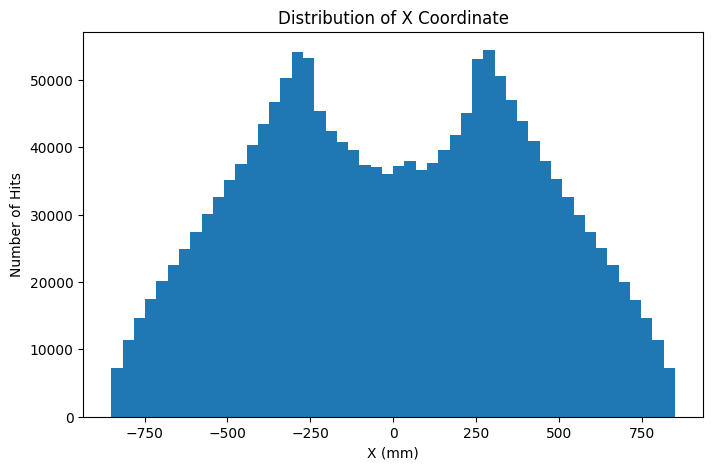

In [75]:
# hits distribution on x coordinate
plt.figure(figsize=(8,5))

plt.hist(df["x"], bins=50)

plt.title("Distribution of X Coordinate")
plt.xlabel("X (mm)")
plt.ylabel("Number of Hits")

plt.show()

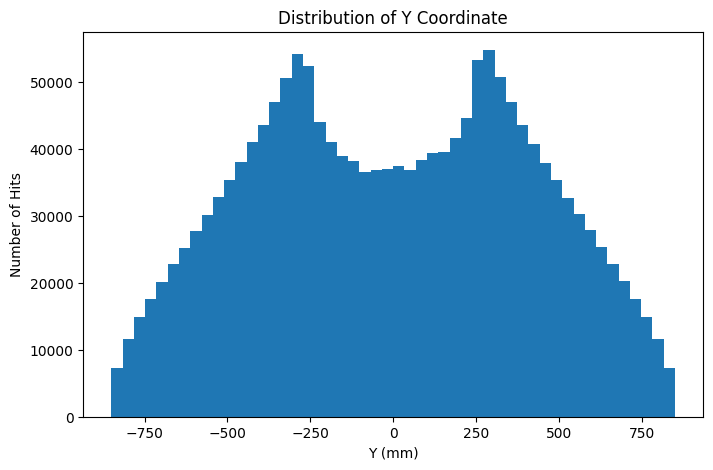

In [76]:
# hits distribution on y coordinate
plt.figure(figsize=(8,5))

plt.hist(df["y"], bins=50)

plt.title("Distribution of Y Coordinate")
plt.xlabel("Y (mm)")
plt.ylabel("Number of Hits")

plt.show()

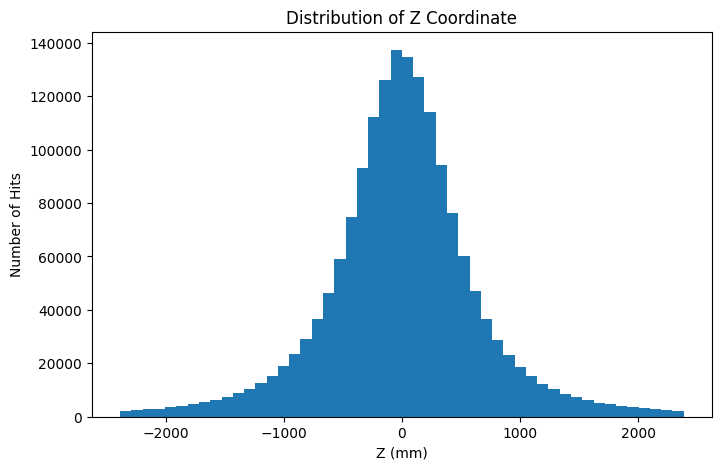

In [77]:
# hits distribution on z coordinate
plt.figure(figsize=(8,5))

plt.hist(df["z"], bins=50)

plt.title("Distribution of Z Coordinate")
plt.xlabel("Z (mm)")
plt.ylabel("Number of Hits")

plt.show()

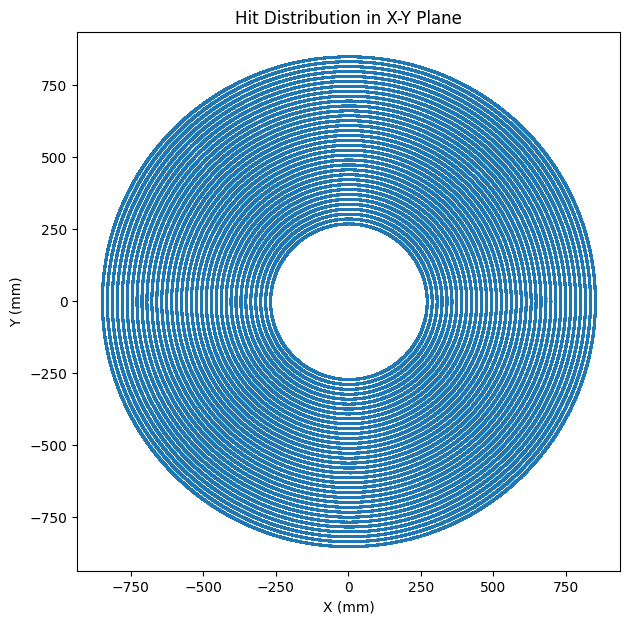

In [78]:
plt.figure(figsize=(7,7))

plt.scatter(df["x"], df["y"], s=1)

plt.title("Hit Distribution in X-Y Plane")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")

plt.show()

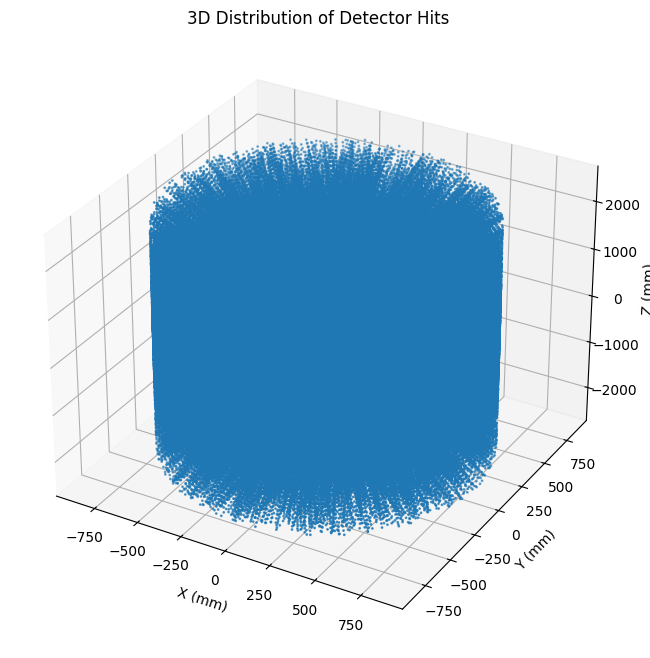

In [79]:
# 3D plot to visualize hits on x y z coord
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["x"],
    df["y"],
    df["z"],
    s=1
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title("3D Distribution of Detector Hits")

plt.show()

In [80]:
# calculate distance of hits from center of detector
df["radius"] = np.sqrt(df["x"]**2 + df["y"]**2)
print(df[["x", "y", "radius"]].head())

            x           y      radius
0 -239.513881 -124.766384  270.062122
1 -253.874712 -134.044343  287.089281
2 -268.044523 -143.534264  304.055836
3 -282.397518 -153.034025  321.197402
4 -296.584347 -162.728275  338.293905


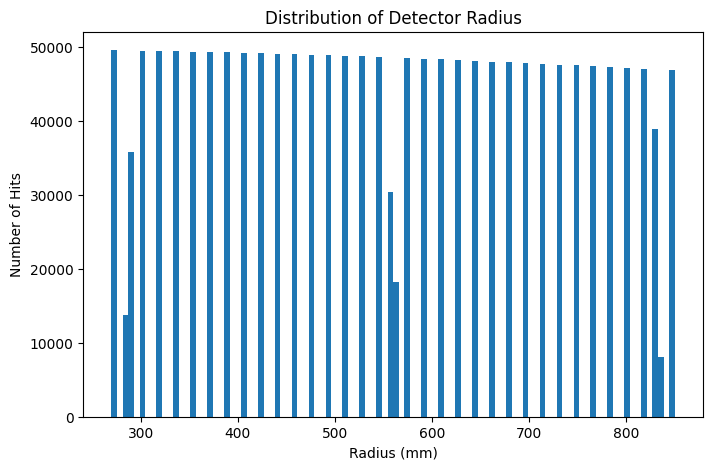

In [81]:
df["radius"] = np.sqrt(df["x"]**2 + df["y"]**2)

plt.figure(figsize=(8,5))
plt.hist(df["radius"], bins=100)
plt.xlabel("Radius (mm)")
plt.ylabel("Number of Hits")
plt.title("Distribution of Detector Radius")
plt.show()

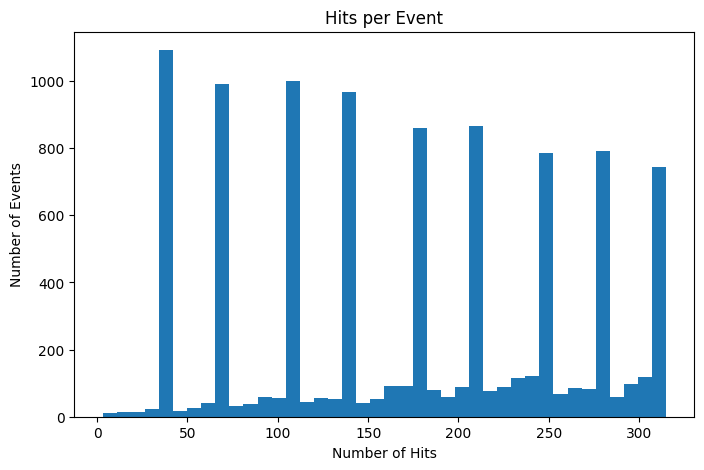

In [82]:
# hits per event 
hits_per_event = df.groupby("event_id").size()

plt.figure(figsize=(8,5))
plt.hist(hits_per_event, bins=40)

plt.title("Hits per Event")
plt.xlabel("Number of Hits")
plt.ylabel("Number of Events")

plt.show()

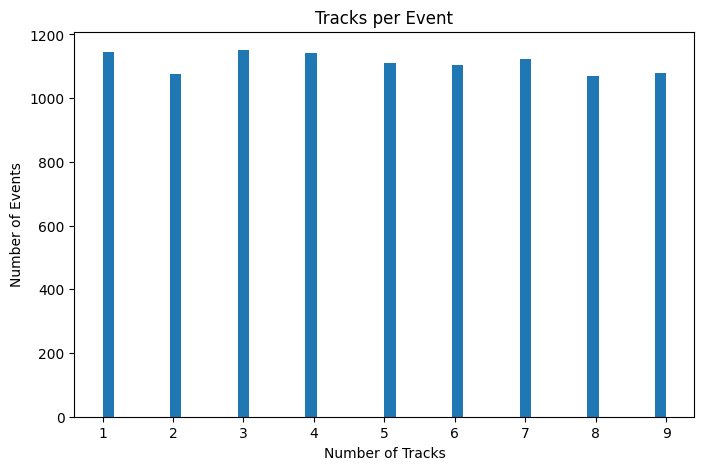

In [83]:
# tracks per event 
tracks_per_event = df.groupby("event_id")["track_id"].nunique()

plt.figure(figsize=(8,5))
plt.hist(tracks_per_event, bins=50)

plt.title("Tracks per Event")
plt.xlabel("Number of Tracks")
plt.ylabel("Number of Events")

plt.show()

In [84]:
df["track_id"].nunique()

9

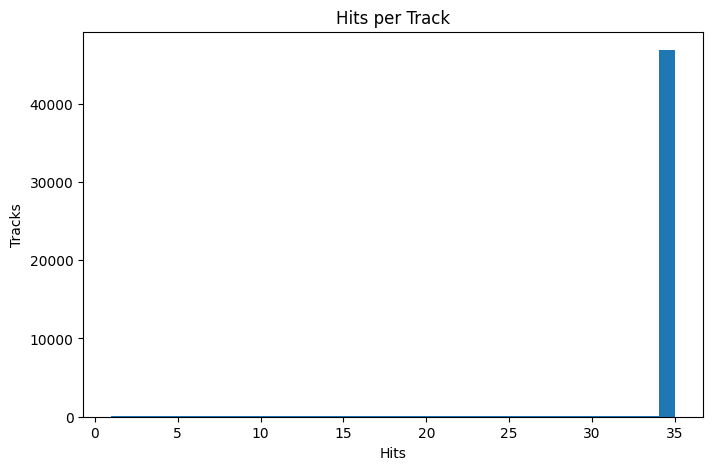

In [85]:
hits_per_track = df.groupby(["event_id","track_id"]).size()

plt.figure(figsize=(8,5))
plt.hist(hits_per_track, bins=35)

plt.title("Hits per Track")
plt.xlabel("Hits")
plt.ylabel("Tracks")

plt.show()

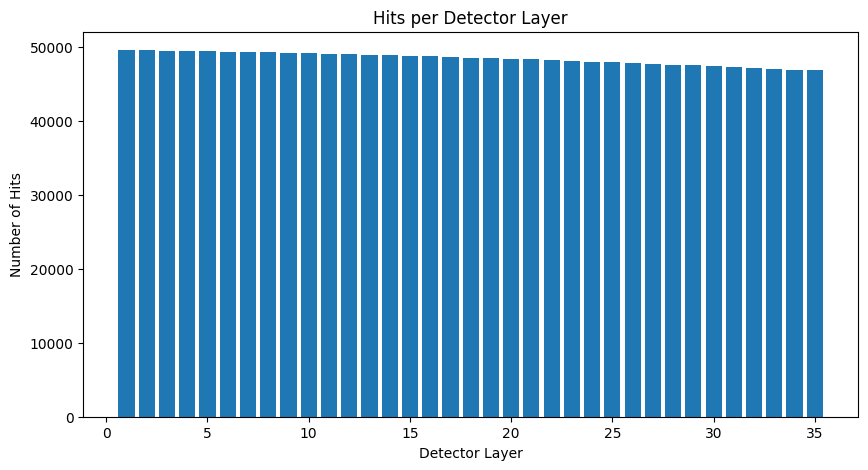

In [86]:
layer_hits = df["station"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.bar(layer_hits.index, layer_hits.values)

plt.xlabel("Detector Layer")
plt.ylabel("Number of Hits")
plt.title("Hits per Detector Layer")

plt.show()

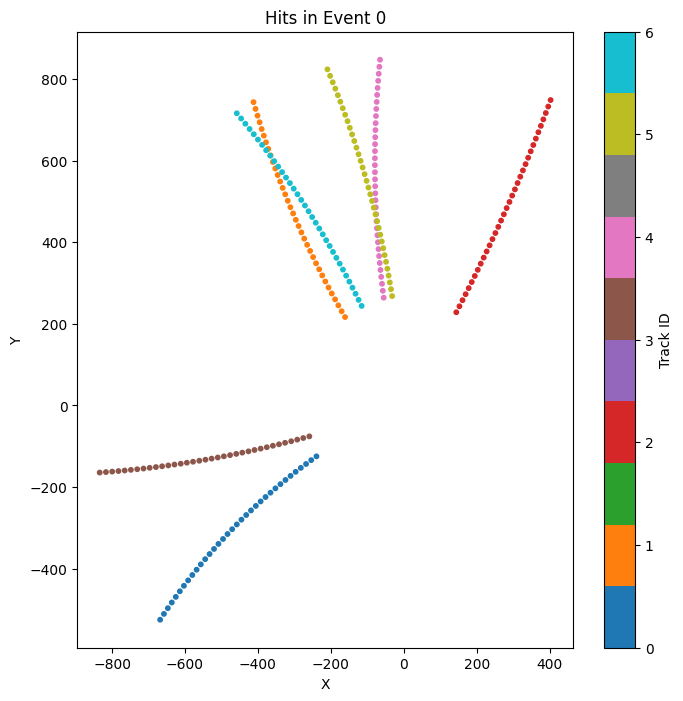

In [87]:
event = df[df["event_id"] == 0]

plt.figure(figsize=(8,8))

plt.scatter(
    event["x"],
    event["y"],
    c=event["track_id"],
    s=10,
    cmap="tab10"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Hits in Event 0")

plt.colorbar(label="Track ID")

plt.show()

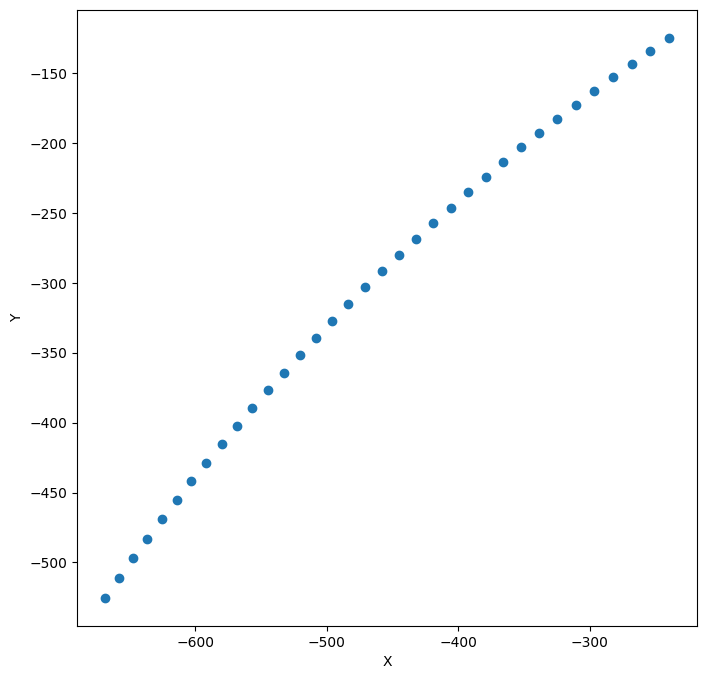

In [88]:
track = df[
    (df["event_id"] == 0) &
    (df["track_id"] == 0)
]

plt.figure(figsize=(8,8))

plt.scatter(track["x"], track["y"])

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

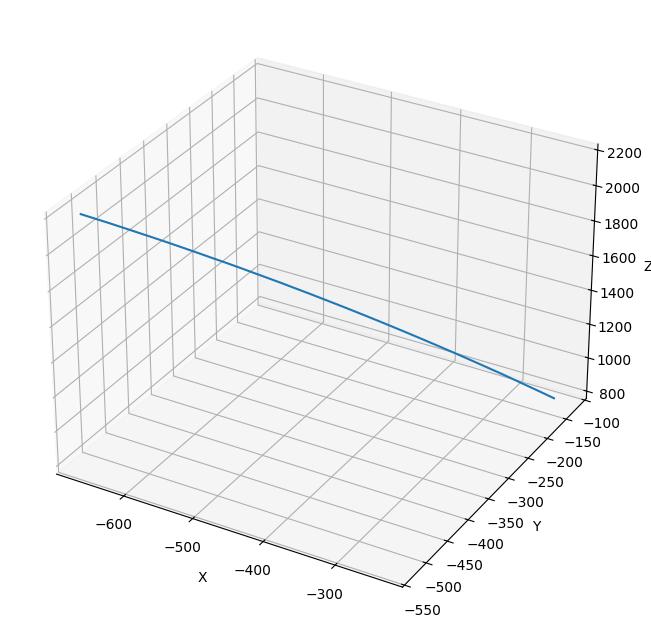

In [89]:


track = df[
    (df["event_id"] == 0) &
    (df["track_id"] == 0)
]

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.plot(
    track["x"],
    track["y"],
    track["z"]
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

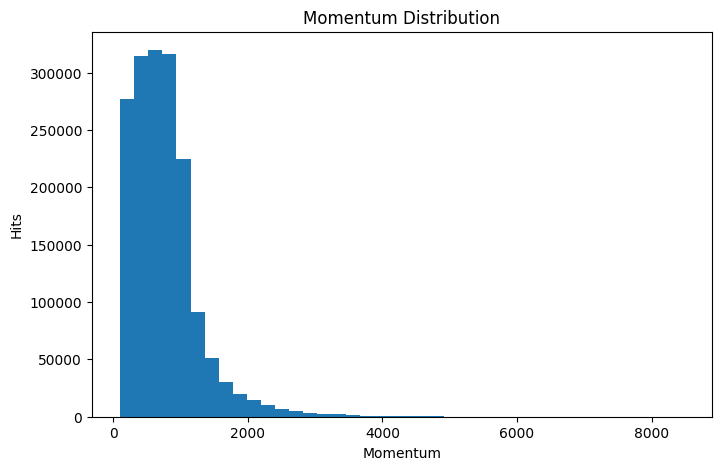

In [90]:
df["momentum"] = np.sqrt(
    df["px"]**2 +
    df["py"]**2 +
    df["pz"]**2
)

plt.figure(figsize=(8,5))

plt.hist(df["momentum"], bins=40)

plt.xlabel("Momentum")
plt.ylabel("Hits")

plt.title("Momentum Distribution")

plt.show()

In [91]:
df["pt"] = np.sqrt(
    df["px"]**2 +
    df["py"]**2
)

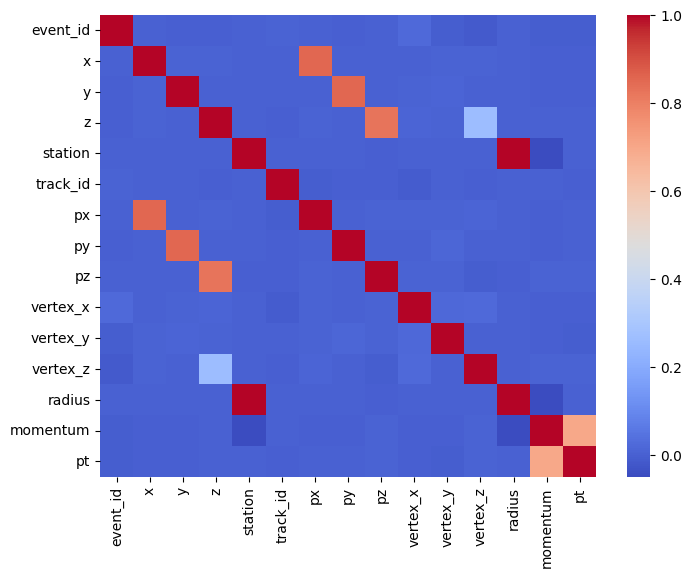

In [92]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

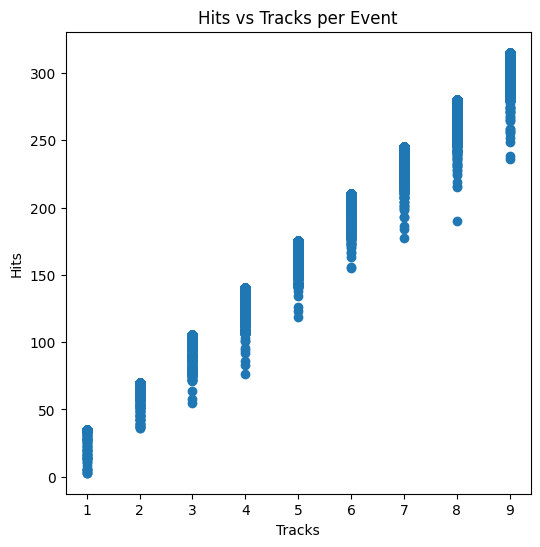

In [93]:
summary = df.groupby("event_id").agg(
    hits=("track_id","size"),
    tracks=("track_id","nunique")
)

plt.figure(figsize=(6,6))

plt.scatter(summary["tracks"], summary["hits"])

plt.xlabel("Tracks")
plt.ylabel("Hits")

plt.title("Hits vs Tracks per Event")

plt.show()

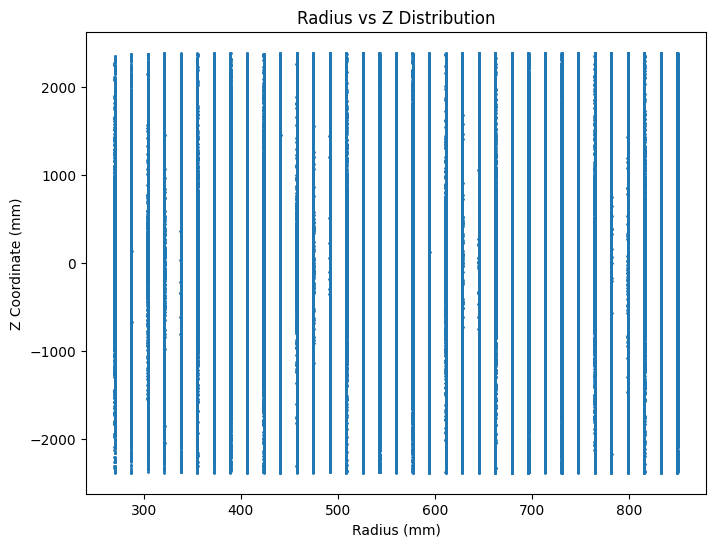

In [94]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["radius"],
    df["z"],
    s=1
)

plt.title("Radius vs Z Distribution")
plt.xlabel("Radius (mm)")
plt.ylabel("Z Coordinate (mm)")

plt.show()

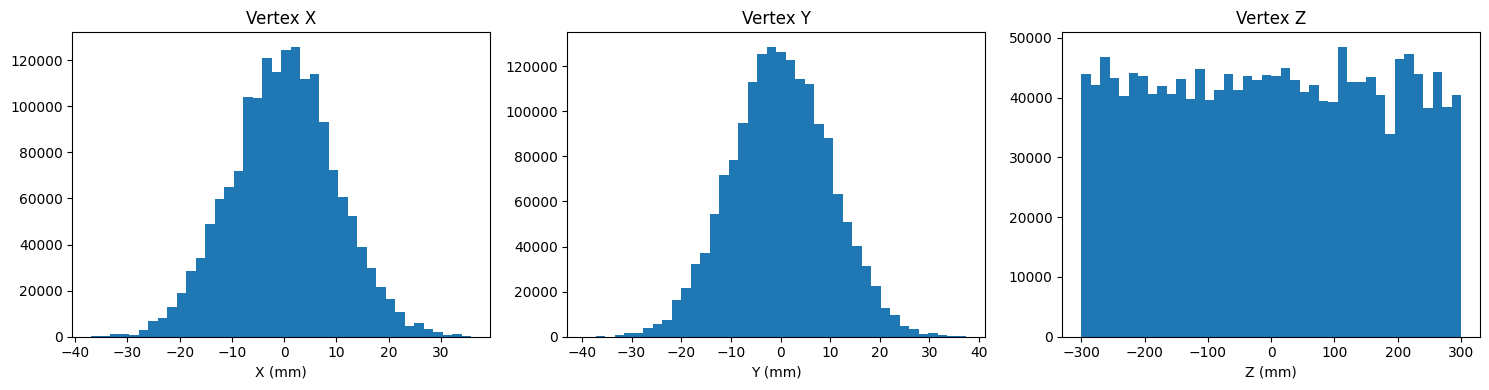

In [95]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)

plt.hist(df["vertex_x"], bins=40)

plt.title("Vertex X")

plt.xlabel("X (mm)")

plt.subplot(1,3,2)

plt.hist(df["vertex_y"], bins=40)

plt.title("Vertex Y")

plt.xlabel("Y (mm)")

plt.subplot(1,3,3)

plt.hist(df["vertex_z"], bins=40)

plt.title("Vertex Z")

plt.xlabel("Z (mm)")

plt.tight_layout()

plt.show()

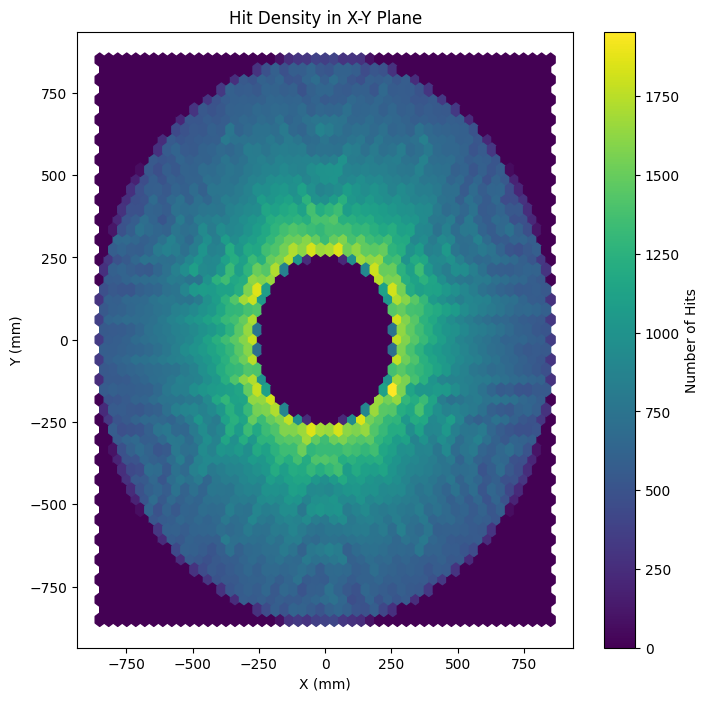

In [96]:
plt.figure(figsize=(8,8))

plt.hexbin(
    df["x"],
    df["y"],
    gridsize=50,
    cmap="viridis"
)

plt.colorbar(label="Number of Hits")

plt.title("Hit Density in X-Y Plane")

plt.xlabel("X (mm)")

plt.ylabel("Y (mm)")

plt.show()

In [97]:
print(df.dtypes)

event_id      int64
x           float64
y           float64
z           float64
station       int64
track_id      int64
px          float64
py          float64
pz          float64
vertex_x    float64
vertex_y    float64
vertex_z    float64
radius      float64
momentum    float64
pt          float64
dtype: object


In [98]:
df.to_csv(
    "clean_signal_hits.tsv",
    sep="\t",
    index=False
)

Duplicate rows: 0
